Fitting the Model

In [1]:
import numpy as np
import numpy.linalg as la
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import librosa
from scipy.special import softmax
from scipy import stats

In [2]:
df = pd.read_csv("time_series_US_20031231-1800_20261003-1348.csv")
df.head()

,Time,golf
0,2004-01-01,45
1,2004-02-01,50
2,2004-03-01,63
3,2004-04-01,79
4,2004-05-01,79


In [7]:
y = df['golf']
n = len(df)
t = np.arange(n)


In [11]:
def design_matrix(f):
    return np.column_stack([np.ones(n),t, t**2,np.cos(2*np.pi*f*t), np.sin(2*np.pi*f*t)])

def log_post(f):
    X = design_matrix(f)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    rss = np.sum((y - X@beta)**2)
    sign, logdet = np.linalg.slogdet(X.T @ X)
    return -.5*logdet - (n-5)/2 * np.log(rss)

f_grid = np.linspace(.05,.1,20000)
lp = np.array([log_post(f) for f in f_grid])
post = softmax(lp)
f_hat = f_grid[np.argmax(post)]
cdf = np.cumsum(post)

f_lo = f_grid[np.searchsorted(cdf,.025)]
f_hi = f_grid[np.searchsorted(cdf,.975)]
print(f"f_hat = {f_hat}, 95% interval = [{f_lo}, {f_hi}]")



f_hat = 0.08341417070853543, 95% interval = [0.08333166658332916, 0.08349667483374168]


Part B

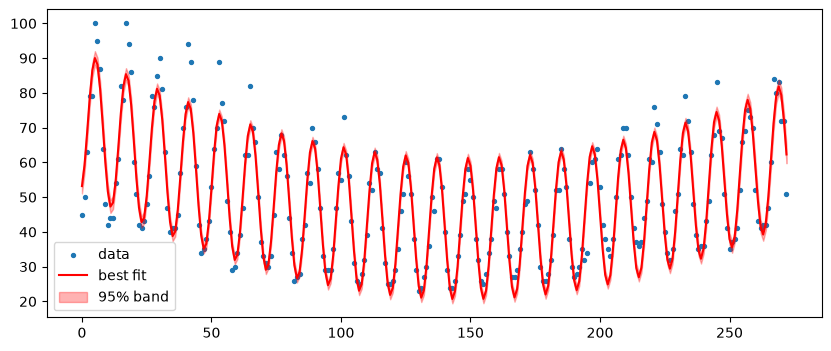

In [ ]:
N = 2000
f_samples = np.random.choice(f_grid, size=N, p=post)
curves = np.empty((N, n))

for k, f in enumerate(f_samples):
    X = design_matrix(f)
    XtX_inv = np.linalg.inv(X.T @ X)
    beta_hat = XtX_inv @ X.T @ y
    rss = np.sum((y - X @ beta_hat)**2)
    sigma2 = rss / np.random.chisquare(n - 5)
    beta = np.random.multivariate_normal(beta_hat, sigma2 * XtX_inv)
    curves[k] = X @ beta

lower, upper = np.percentile(curves, [2.5, 97.5], axis=0)
X_hat = design_matrix(f_hat)
fit = X_hat @ np.linalg.lstsq(X_hat, y, rcond=None)[0]

plt.figure(figsize=(10, 4))
plt.scatter(t, y, s=8, label='data')
plt.plot(t, fit, color='red', label='best fit')
plt.fill_between(t, lower, upper, color='red', alpha=0.3, label='95% band')
plt.legend()
plt.show()


Part C

The model does well at capturign the overall trend. Specifically it capture the yearly cycle quite well as well as the long term u shape we see in the graph. However it fails to accurately capture the peaks. Leading me to say the model is not fully appropriate for this data.